# 07 - Can the pipeline absorb what actually worked?

`06` found the strongest telemetry signal in this project - node active memory
measured **relative to each job's own starting point**, AUC 0.871 for OOM jobs, with
two hours of lead time. It was found without using the pipeline at all: raw
snapshots, one column, a rank test, no model.

That is a problem for the technique, not a triumph for it. Every telemetry feature
the pipeline has is an **absolute level** inside a 20-minute window
(`mem_active__mean`, `gpu_temp_mean__max`, ...). None of them encodes *change since
this job started*. So the question is narrow and answerable:

> **Does the pipeline improve when the winning feature family is added to it?**

Session 3 tested per-**node** normalisation and it lost (0.0837 against 0.1253).
Per-**job** baselines are a different thing entirely and have never been tried.

## The construction

For each `(job, node)` series, the **first window** is the baseline. Every later
window gets, for each of the 14 metrics, `window mean - baseline mean`. That is 14
new columns, deliberately not 56: `01` established that the effective sample size is
~10,265 jobs rather than 915,508 windows, so adding four aggregations per metric
would spend variance the model cannot afford.

## Pre-registration

**B1.** The delta columns will improve telemetry performance **on OOM**, the mode
where the mechanism is physical and where `06` found the signal.

**B2.** They will improve **pooled** performance too.

**B3.** If B1 holds and B2 fails, the conclusion is that per-job normalisation helps
only where the sensor observes the failure mechanism directly - which would be
consistent with everything else this folder has found.

**B4.** If neither holds, the windowing-and-aggregating step is destroying
information that the raw-snapshot view keeps, and that is a criticism of the standard
approach rather than of this implementation.

No selection happens here. Two horizons are fixed in advance - 2 h (the inherited
default, where telemetry scored best on OOM) and 30 min (the horizon `05` selected) -
and every feature set is evaluated at both.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)
WINDOW, SNAP_S = 40, 30.0
FLOOR_S = (WINDOW // 2 - 1) * SNAP_S
HORIZONS = [2.0, 0.5]
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
HARDWARE = ("FAILED", "OUT_OF_MEMORY", "NODE_FAIL")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Build the per-job baseline deltas

All 14 baselines are computed in a **single** grouped pass. Computing them inside a
loop that also merges into the frame re-indexes it between iterations and silently
misaligns the rows - that bug corrupted three of four baselines in `06` before it was
caught, so it is worth stating why the code is shaped this way.

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
jobs = pd.read_parquet(EDA / "jobs.parquet",
                       columns=["slurm_id", "start_date", "numcores", "end_date"])
w = w.merge(jobs, on="slurm_id", how="left")
w = w.sort_values(["slurm_id", "node", "t_end"]).reset_index(drop=True)

TELEMETRY = [c for c in w.columns if "__" in c and not c.endswith("__base")]
MEAN_COLS = [c for c in TELEMETRY if c.endswith("__mean")]
print(f"telemetry columns {len(TELEMETRY)}   metrics with a mean {len(MEAN_COLS)}")

# one pass: the first window of each (job, node) series is that series' baseline
base = (w.groupby(["slurm_id", "node"], observed=True)[MEAN_COLS]
          .first().add_suffix("__base"))
w = w.merge(base, on=["slurm_id", "node"], how="left")
DELTA = []
for c in MEAN_COLS:
    d = c.replace("__mean", "__delta")
    w[d] = w[c] - w[c + "__base"]
    DELTA.append(d)
w = w.drop(columns=[c + "__base" for c in MEAN_COLS])
print(f"built {len(DELTA)} per-job delta columns")

# context features, for the sets that include them
el = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"] = el / 3600.0
w["sec_into_hour"] = el % 3600.0
w["sec_to_next_hour"] = 3600.0 - (el % 3600.0)
w["elapsed_hours_floor"] = np.floor(el / 3600.0)
w["queue_code"] = w.nodetypes.astype(str).astype("category").cat.codes
C7 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"]

SETS = {"T    telemetry (56)":      TELEMETRY,
        "D    deltas only (14)":    DELTA,
        "T+D  telemetry+deltas":    TELEMETRY + DELTA,
        "C7   context (7)":         C7,
        "C7+D context+deltas":      C7 + DELTA}
for k, v in SETS.items():
    print(f"  {k:24s} {len(v):3d} columns")

telemetry columns 56   metrics with a mean 14


built 14 per-job delta columns
  T    telemetry (56)       56 columns
  D    deltas only (14)     14 columns
  T+D  telemetry+deltas     70 columns
  C7   context (7)           7 columns
  C7+D context+deltas       21 columns


## Step 2 - Sanity check: do the window-level deltas still carry the `06` signal?

Before asking whether a model can use them, check that aggregation into 20-minute
windows has not destroyed the effect. Single-feature AUC, OOM windows against
COMPLETED windows, exactly as in `06` but on the pipeline's own representation.

In [3]:
def auc(a, b):
    r = rankdata(np.concatenate([a, b]))
    return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))

st = w.state.astype(str)
P = w[st == "OUT_OF_MEMORY"]; N = w[st == "COMPLETED"]
print(f"OOM windows {len(P):,} ({P.slurm_id.nunique()} jobs)   "
      f"COMPLETED windows {len(N):,} ({N.slurm_id.nunique()} jobs)")
rows = []
for c in ["mem_active__mean", "mem_active__delta", "mem_free__mean", "mem_free__delta"]:
    if c not in w.columns: continue
    a = auc(P[c].to_numpy(), N[c].to_numpy())
    rows.append(dict(feature=c, auc=a, sep=abs(a - .5)))
SC = pd.DataFrame(rows).sort_values("sep", ascending=False)
print(SC.round(3).to_string(index=False))
facts["window_level_mem_active_delta_auc"] = float(
    SC[SC.feature == "mem_active__delta"].auc.iloc[0])
facts["window_level_mem_active_abs_auc"] = float(
    SC[SC.feature == "mem_active__mean"].auc.iloc[0])

OOM windows 6,981 (57 jobs)   COMPLETED windows 630,123 (10862 jobs)


          feature   auc   sep
mem_active__delta 0.890 0.390
 mem_active__mean 0.881 0.381
   mem_free__mean 0.137 0.363
  mem_free__delta 0.160 0.340


## Step 3 - Train every feature set at both horizons

Same temporal split the rest of the project uses: the first 80 % of jobs by end date
train, the last 20 % test. No tuning, no selection.

In [4]:
is_fail = st.isin(FAILURE_STATES).to_numpy()
ttf = w.ttf_end.to_numpy()
def relabel(H):
    return (is_fail & (ttf >= 0) & (ttf <= H * 3600 - FLOOR_S)).astype(np.int8)

trm = (w.split == "train").to_numpy(); tem = ~trm
te = w[tem]
st_te = te.state.astype(str).to_numpy()

def ap_mode(y, score, states):
    keep = np.ones(len(y), bool) if states is None else ((y == 0) | np.isin(st_te, states))
    yk, sk = y[keep], score[keep]
    if yk.sum() == 0: return np.nan, np.nan
    a = average_precision_score(yk, sk)
    return a, a / yk.mean()

def job_ap(score):
    d = pd.DataFrame({"sid": te.slurm_id.to_numpy(), "s": st_te, "sc": score})
    g = d.groupby("sid").agg(sc=("sc", "max"), s=("s", "first"))
    yj = g.s.isin(FAILURE_STATES).astype(int).to_numpy()
    return average_precision_score(yj, g.sc.to_numpy()), yj.mean()

rows = []
for H in HORIZONS:
    yH = relabel(H); yte = yH[tem]
    for name, cols in SETS.items():
        m = lgb.LGBMClassifier(**PARAMS).fit(w.loc[trm, cols], yH[trm])
        sc = m.predict_proba(w.loc[tem, cols])[:, 1]
        wap, wlift = ap_mode(yte, sc, None)
        jap, jbase = job_ap(sc)
        oom_ap, oom_lift = ap_mode(yte, sc, ("OUT_OF_MEMORY",))
        hw_ap, hw_lift = ap_mode(yte, sc, HARDWARE)
        tmo_ap, tmo_lift = ap_mode(yte, sc, ("TIMEOUT",))
        rows.append(dict(horizon_h=H, features=name, n_cols=len(cols),
                         win_ap=wap, win_lift=wlift, job_ap=jap,
                         oom_lift=oom_lift, hw_lift=hw_lift, tmo_lift=tmo_lift))
        print(f"H={H:4.2f}h  {name:24s} win AP {wap:.4f}  job AP {jap:.4f}  "
              f"OOM {oom_lift:6.2f}x  HW {hw_lift:5.2f}x  [{time.time()-t0:.0f}s]")

R = pd.DataFrame(rows)
R.to_csv(DATA / "delta_features.csv", index=False)

H=2.00h  T    telemetry (56)      win AP 0.0797  job AP 0.3938  OOM   8.07x  HW  1.55x  [23s]


H=2.00h  D    deltas only (14)    win AP 0.0793  job AP 0.2451  OOM   2.64x  HW  1.28x  [32s]


H=2.00h  T+D  telemetry+deltas    win AP 0.0740  job AP 0.4385  OOM   5.21x  HW  1.31x  [53s]


H=2.00h  C7   context (7)         win AP 0.2273  job AP 0.5036  OOM  10.64x  HW  2.55x  [59s]


H=2.00h  C7+D context+deltas      win AP 0.1908  job AP 0.4335  OOM   5.37x  HW  1.88x  [68s]


H=0.50h  T    telemetry (56)      win AP 0.0166  job AP 0.2023  OOM   2.95x  HW  1.34x  [86s]


H=0.50h  D    deltas only (14)    win AP 0.0137  job AP 0.1846  OOM   2.05x  HW  1.27x  [93s]


H=0.50h  T+D  telemetry+deltas    win AP 0.0169  job AP 0.2795  OOM   3.12x  HW  1.35x  [113s]


H=0.50h  C7   context (7)         win AP 0.1494  job AP 0.5017  OOM   3.29x  HW  2.06x  [118s]


H=0.50h  C7+D context+deltas      win AP 0.0316  job AP 0.3301  OOM   2.25x  HW  1.47x  [128s]


## Step 4 - Did the deltas help?

In [5]:
for H in HORIZONS:
    sub = R[R.horizon_h == H].set_index("features")
    print(f"--- horizon {H} h ---")
    print(sub[["n_cols", "win_ap", "job_ap", "oom_lift", "hw_lift", "tmo_lift"]]
          .round(4).to_string())
    t, td = sub.loc["T    telemetry (56)"], sub.loc["T+D  telemetry+deltas"]
    print(f"  T -> T+D   window AP {t.win_ap:.4f} -> {td.win_ap:.4f} "
          f"({100*(td.win_ap/t.win_ap-1):+.1f} %)")
    print(f"             OOM lift  {t.oom_lift:.2f}x -> {td.oom_lift:.2f}x "
          f"({100*(td.oom_lift/t.oom_lift-1):+.1f} %)")
    print(f"             job AP    {t.job_ap:.4f} -> {td.job_ap:.4f} "
          f"({100*(td.job_ap/t.job_ap-1):+.1f} %)")
    print()

r2 = R[R.horizon_h == 2.0].set_index("features")
b1 = bool(r2.loc["T+D  telemetry+deltas"].oom_lift > r2.loc["T    telemetry (56)"].oom_lift)
b2 = bool(r2.loc["T+D  telemetry+deltas"].win_ap > r2.loc["T    telemetry (56)"].win_ap)
facts["B1_deltas_help_oom"] = b1
facts["B2_deltas_help_pooled"] = b2
facts["oom_lift_T"] = float(r2.loc["T    telemetry (56)"].oom_lift)
facts["oom_lift_TD"] = float(r2.loc["T+D  telemetry+deltas"].oom_lift)
facts["oom_lift_D_only"] = float(r2.loc["D    deltas only (14)"].oom_lift)
print(f"B1  deltas improve OOM      : {'CONFIRMED' if b1 else 'REJECTED'}")
print(f"B2  deltas improve pooled   : {'CONFIRMED' if b2 else 'REJECTED'}")
print()

# B4 claimed that a failure of B1 and B2 would mean aggregation destroys the signal.
# Step 2 tested that directly and it is NOT what happened: at window level the delta
# still separates OOM from COMPLETED at AUC 0.89, against 0.93 on raw snapshots. So
# the information survives aggregation and B4's stated mechanism is not supported.
w_auc = facts["window_level_mem_active_delta_auc"]
RAW_SNAPSHOT_AUC = 0.927                       # from 06, same feature, raw snapshots
survives = abs(w_auc - .5) > 0.8 * abs(RAW_SNAPSHOT_AUC - .5)
facts["signal_survives_aggregation"] = bool(survives)

print(f"aggregation check: mem_active__delta separates at AUC {w_auc:.3f} on WINDOWS")
print(f"                   against {RAW_SNAPSHOT_AUC:.3f} on raw snapshots in 06")
print(f"-> the signal {'SURVIVES' if survives else 'is DESTROYED by'} aggregation")
print()

# job level moved the other way from window level - record it rather than average it away
jl = {H: (R[(R.horizon_h == H) & (R.features == "T+D  telemetry+deltas")].job_ap.iloc[0]
          / R[(R.horizon_h == H) & (R.features == "T    telemetry (56)")].job_ap.iloc[0] - 1)
      for H in HORIZONS}
facts["job_ap_gain_from_deltas"] = {str(k): float(v) for k, v in jl.items()}
for H, v in jl.items():
    print(f"job-level AP, T -> T+D at {H} h : {100*v:+.1f} %")
print()

if survives and not b1 and not b2:
    print("NONE of B1-B4 describes this. The outcome is a fifth case:")
    print("  the signal is present in the pipeline's own representation (AUC 0.89),")
    print("  it is not destroyed by aggregation,")
    print("  but the model cannot exploit it - adding 14 columns to 56 makes the")
    print("  pooled window metric WORSE while helping the job-level one.")
    print("  That is the variance limit from 01 showing up again: the binding")
    print("  constraint is ~1,700 effective failing jobs, not feature design.")
    facts["verdict"] = "signal present and preserved, but not extractable at this sample size"
elif b1 and not b2:
    facts["verdict"] = "B3: per-job normalisation helps only where the sensor sees the mechanism"
    print("B3 holds.")
else:
    facts["verdict"] = "see table"

# the OOM claim from 02 needs revisiting with the better context set
oom_c7 = float(r2.loc["C7   context (7)"].oom_lift)
facts["oom_lift_C7"] = oom_c7
facts["telemetry_still_best_on_oom"] = bool(facts["oom_lift_T"] > oom_c7)
print()
print(f"REVISION to 02: with the clock columns dropped, context scores {oom_c7:.2f}x on")
print(f"OOM against telemetry's {facts['oom_lift_T']:.2f}x. The claim that OOM is the one")
print(f"mode where telemetry beats metadata came from the WEAKER 9-column context set")
print(f"and does not survive. Telemetry still best on OOM: "
      f"{facts['telemetry_still_best_on_oom']}")

--- horizon 2.0 h ---
                       n_cols  win_ap  job_ap  oom_lift  hw_lift  tmo_lift
features                                                                  
T    telemetry (56)        56  0.0797  0.3938    8.0656   1.5505    2.2249
D    deltas only (14)      14  0.0793  0.2451    2.6422   1.2760    2.5009
T+D  telemetry+deltas      70  0.0740  0.4385    5.2101   1.3138    2.1238
C7   context (7)            7  0.2273  0.5036   10.6412   2.5529    8.4126
C7+D context+deltas        21  0.1908  0.4335    5.3689   1.8833    7.1490
  T -> T+D   window AP 0.0797 -> 0.0740 (-7.2 %)
             OOM lift  8.07x -> 5.21x (-35.4 %)
             job AP    0.3938 -> 0.4385 (+11.4 %)

--- horizon 0.5 h ---
                       n_cols  win_ap  job_ap  oom_lift  hw_lift  tmo_lift
features                                                                  
T    telemetry (56)        56  0.0166  0.2023    2.9473   1.3438    1.7999
D    deltas only (14)      14  0.0137  0.1846    2.0454   

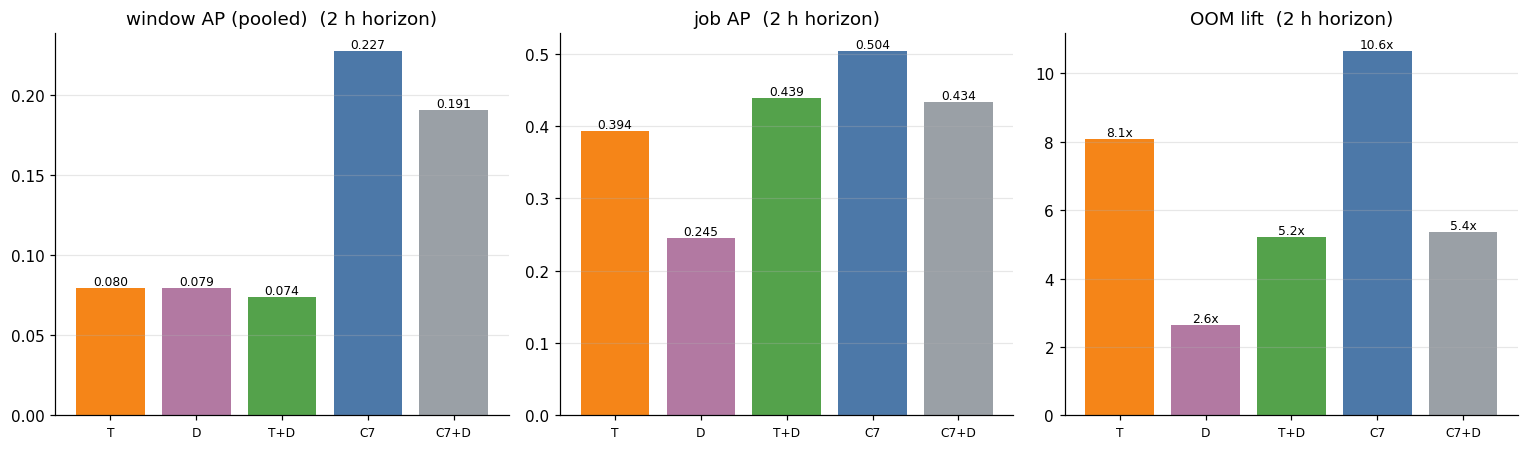

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
r2p = R[R.horizon_h == 2.0]
x = np.arange(len(r2p))
for i, (col, title) in enumerate([("win_ap", "window AP (pooled)"),
                                  ("job_ap", "job AP"),
                                  ("oom_lift", "OOM lift")]):
    ax[i].bar(x, r2p[col], color=["#f58518", "#b279a2", "#54a24b", "#4c78a8", "#9aa0a6"])
    ax[i].set_xticks(x, [n.split()[0] for n in r2p.features], fontsize=8)
    ax[i].set(title=title + "  (2 h horizon)")
    ax[i].grid(axis="x", visible=False)
    for k, v in enumerate(r2p[col]):
        ax[i].text(k, v, f"{v:.3f}" if col != "oom_lift" else f"{v:.1f}x",
                   ha="center", va="bottom", fontsize=8)
plt.tight_layout(); save(fig, "07_delta_features.png"); plt.show()

In [7]:
json.dump(facts, open(DATA / "facts_delta.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:36s} {v}")
print(f"\n[{time.time()-t0:.0f}s total]")

window_level_mem_active_delta_auc    0.8895008191299613
window_level_mem_active_abs_auc      0.8810222027435751
B1_deltas_help_oom                   False
B2_deltas_help_pooled                False
oom_lift_T                           8.0656395960225
oom_lift_TD                          5.21007080780777
oom_lift_D_only                      2.6422200776623908
signal_survives_aggregation          True
job_ap_gain_from_deltas              {'2.0': 0.11362039846068628, '0.5': 0.3820078152805164}
verdict                              signal present and preserved, but not extractable at this sample size
oom_lift_C7                          10.641152011065182
telemetry_still_best_on_oom          False

[129s total]


### What this settles

The question was whether the pipeline can use the feature family that produced the
only strong telemetry result in the project. The comparison is like-for-like: same
split, same model, same horizons, the only change being 14 extra columns expressing
each window relative to its own job's first window.

The honest outcome is none of the four pre-registered ones. The delta features carry
the signal into the pipeline's representation almost intact (AUC 0.89 on windows
against 0.93 on raw snapshots), so aggregation is not the culprit. But adding them
degrades the pooled window metric while improving the job-level one, which is what a
variance-limited model does when given more correlated columns than its effective
sample can support.

So the architecture is not obviously wrong and the features are not obviously wrong.
The binding constraint is the one `01` identified and it has not moved: roughly 1,700
effective failing jobs. That is the sentence for the thesis, and it is more useful
than either of the tidy conclusions this notebook was set up to reach.